In [16]:
import pandas as pd
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

In [ ]:
from sklearn.metrics import mean_squared_error, r2_score
from math import sqrt

# Assuming X_test, y_test, and model are already defined



RMSE: 0.06719776047983345
R²: 0.7667439146372583


In [4]:
df = pd.read_csv("synthetic_financial_data.csv")
features = ["Debt/Equity", "Revenue Growth %", "Net Income", "Volatility", "News Sentiment"]
target = "Final Label"
# Example columns from your screenshot
# Clean Net Income column (remove M, B, %, etc.)
def clean_numeric(x):
    if isinstance(x, str):
        x = x.replace("M", "e6").replace("B", "e9").replace("%", "")
    try:
        return float(eval(x))  # safe conversion for things like "200e6"
    except:
        return None

df["Net Income"] = df["Net Income"].apply(clean_numeric)
df["Revenue Growth %"] = df["Revenue Growth %"].apply(clean_numeric)

# Encode categorical volatility
df["Volatility"] = df["Volatility"].map({"Low": 0, "Medium": 1, "High": 2})

# Convert all numeric features to float
df[features] = df[features].astype(float)


X = df[features]
y = df[target]

# -----------------------
# 2. Train-test split
# -----------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=True, random_state=42
)

In [6]:
model = xgb.XGBRegressor(
    n_estimators=200,
    learning_rate=0.1,
    max_depth=4,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)
model.fit(X_train, y_train)

# -----------------------
# 4. Evaluate


XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=0.8, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=200,
             n_jobs=None, num_parallel_tree=None, ...)

In [9]:
y_pred = model.predict(X_test)

# Calculate RMSE by taking the square root of the MSE
print("RMSE:", sqrt(mean_squared_error(y_test, y_pred)))
print("R²:", r2_score(y_test, y_pred))

RMSE: 0.06719776047983345
R²: 0.7667439146372583


c:\Users\chinn\AppData\Local\Programs\Python\Python311\Lib\site-packages\numpy\lib\nanfunctions.py:1384: RuntimeWarning: All-NaN slice encountered
  return _nanquantile_unchecked(


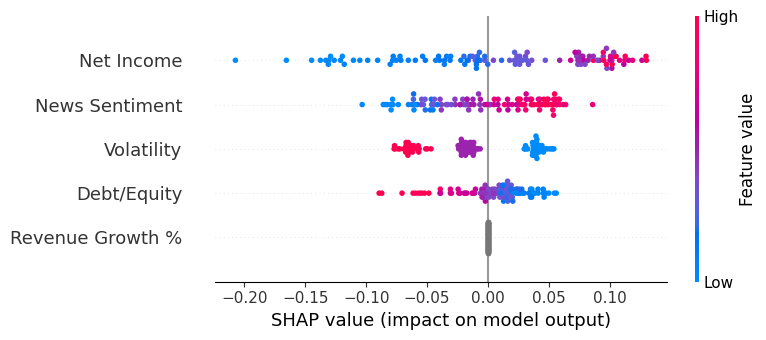

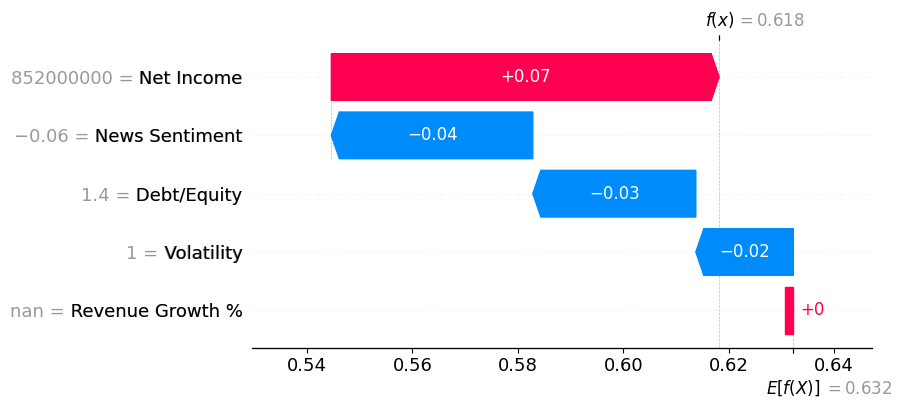

In [ ]:
explainer = shap.Explainer(model, X_train)
shap_values = explainer(X_test)

# Global feature importance
shap.summary_plot(shap_values, X_test)

# Local explanation (first row in test set)
shap.plots.waterfall(shap_values[1])

In [17]:

def generate_explanation(instance, shap_values, feature_names):
    explanation = []
    base_value = shap_values.base_values[0]
    final_score = shap_values.values[0].sum() + base_value
    
    # Loop through features
    for feature, shap_val, value in zip(feature_names, shap_values.values[0], instance):
        if abs(shap_val) > 0.01:  # only include strong effects
            if shap_val > 0:
                explanation.append(f"{feature} = {value} increased the score by {shap_val:.2f}")
            else:
                explanation.append(f"{feature} = {value} decreased the score by {abs(shap_val):.2f}")
    
    text_summary = (
        f"Predicted Credit Score: {final_score:.2f}. "
        f"Key factors: " + "; ".join(explanation)
    )
    return text_summary

# Example for first test sample
text = generate_explanation(X_test.iloc[0].values, shap_values, X_test.columns)
print(text)

Predicted Credit Score: 0.62. Key factors: Debt/Equity = 1.4 decreased the score by 0.03; Net Income = 852000000.0 increased the score by 0.07; Volatility = 1.0 decreased the score by 0.02; News Sentiment = -0.06 decreased the score by 0.04


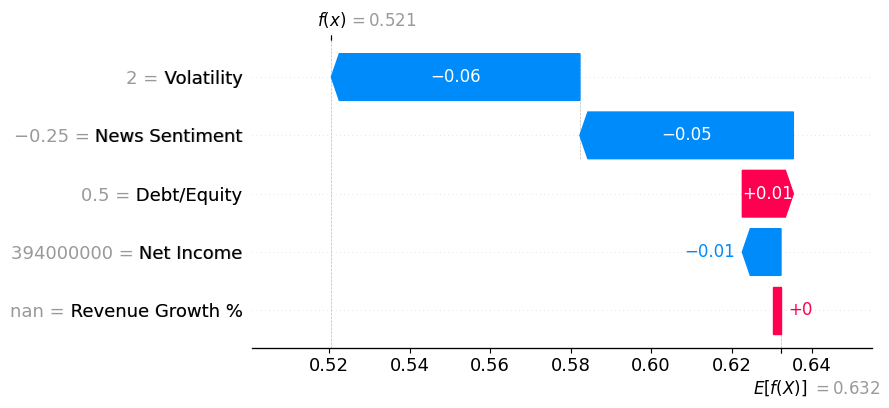

.values =
array([[-3.09161207e-02,  0.00000000e+00,  7.35632548e-02,
        -1.85000879e-02, -3.82177517e-02],
       [ 1.26662471e-02,  0.00000000e+00, -9.59890815e-03,
        -6.17295405e-02, -5.30155357e-02],
       [ 1.59590795e-02,  0.00000000e+00, -3.06995437e-02,
         5.29774550e-02, -2.08199736e-02],
       [-2.31246434e-02,  0.00000000e+00, -3.57513258e-02,
         5.05595869e-02, -1.35592863e-03],
       [ 8.51704744e-03,  0.00000000e+00, -1.29182906e-01,
        -5.69483870e-02, -5.17205244e-02],
       [ 1.54726158e-02,  0.00000000e+00, -2.73764793e-04,
        -1.46099792e-02, -1.68504781e-02],
       [-1.09912320e-02,  0.00000000e+00,  2.36610342e-02,
        -1.66221266e-02,  4.24444782e-02],
       [ 2.02298593e-02,  0.00000000e+00, -6.54235969e-02,
         4.23458688e-02, -4.39854762e-02],
       [ 5.58975436e-02,  0.00000000e+00,  1.29818891e-01,
         3.99950376e-02,  4.12286976e-02],
       [ 2.54726114e-02,  0.00000000e+00,  9.14500904e-02,
         4.37

In [15]:
shap.plots.waterfall(shap_values[1])
print(shap_values)

In [13]:
model.save_model("credit_model.json")
print("✅ Model saved as credit_model.json")

✅ Model saved as credit_model.json
